*@author: petra.boskovic*

In [1]:
#!pip install kagglehub librosa torch torchvision tqdm soundfile

# 1. IMPORTS

In [2]:
import os

import kagglehub
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


# 2. DATASET DOWNLOAD (via kagglehub)

In [3]:
print("Downloading / locating UrbanSound8K dataset via kagglehub...")
DATASET_DIR = kagglehub.dataset_download("chrisfilo/urbansound8k")
print("Dataset available at:", DATASET_DIR)

100%|██████████| 5.61G/5.61G [01:06<00:00, 91.3MB/s]

Extracting files...


Dataset available at: /root/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1


In [4]:
CSV_PATH = os.path.join(DATASET_DIR, "UrbanSound8K.csv")
assert os.path.exists(CSV_PATH), f"Could not find CSV at: {CSV_PATH}"

In [5]:
# The folder layout differs between dataset copies/mounts: some have the fold1..fold10
# directories nested under an "audio" subfolder, others have them directly under the
# dataset root. Detect which one we actually have instead of hardcoding it.
if os.path.exists(os.path.join(DATASET_DIR, "audio", "fold1")):
    AUDIO_DIR = os.path.join(DATASET_DIR, "audio")
elif os.path.exists(os.path.join(DATASET_DIR, "fold1")):
    AUDIO_DIR = DATASET_DIR
else:
    raise FileNotFoundError(
        f"Could not locate fold1 under '{DATASET_DIR}' or '{DATASET_DIR}/audio'. "
        f"Contents found: {os.listdir(DATASET_DIR)}"
    )
print("Audio directory resolved to:", AUDIO_DIR)

Audio directory resolved to: /root/.cache/kagglehub/datasets/chrisfilo/urbansound8k/versions/1


In [6]:
metadata = pd.read_csv(CSV_PATH)
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


# 3. EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
print("Number of samples:", len(metadata))
print("Number of classes:", metadata["class"].nunique())
print("Folds present:", sorted(metadata["fold"].unique()))

Number of samples: 8732
Number of classes: 10
Folds present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [8]:
class_map = metadata[["classID", "class"]].drop_duplicates().sort_values("classID")
print(class_map)

     classID             class
22         0   air_conditioner
9          1          car_horn
1          2  children_playing
0          3          dog_bark
196        4          drilling
122        5     engine_idling
106        6          gun_shot
171        7        jackhammer
114        8             siren
94         9      street_music


In [9]:
print("Missing values per column:")
print(metadata.isna().sum())
print("Duplicated rows:", metadata.duplicated().sum())

Missing values per column:
slice_file_name    0
fsID               0
start              0
end                0
salience           0
fold               0
classID            0
class              0
dtype: int64
Duplicated rows: 0


/tmp/ipykernel_1881/1562542974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, y="class", order=order, palette="viridis")


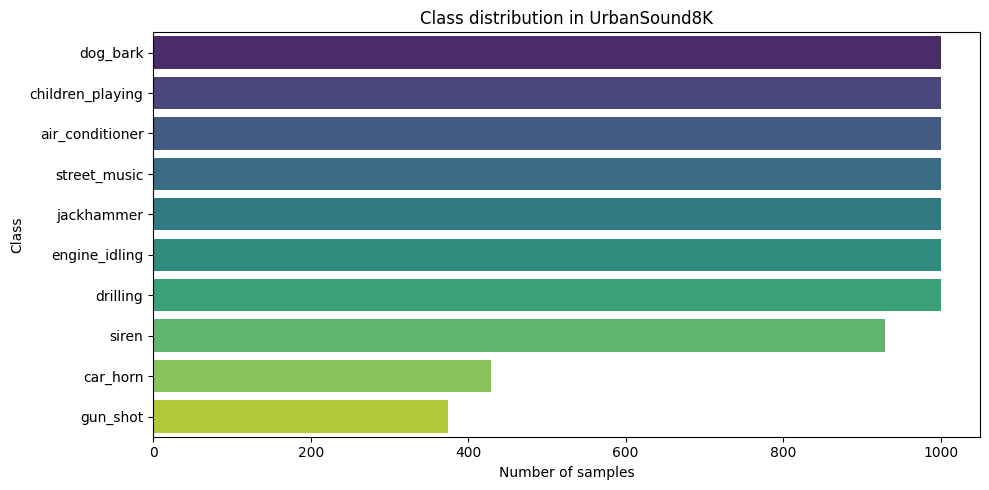

In [10]:
plt.figure(figsize=(10, 5))
order = metadata["class"].value_counts().index
sns.countplot(data=metadata, y="class", order=order, palette="viridis")
plt.title("Class distribution in UrbanSound8K")
plt.xlabel("Number of samples")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1881/1436279954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, x="fold", palette="mako")


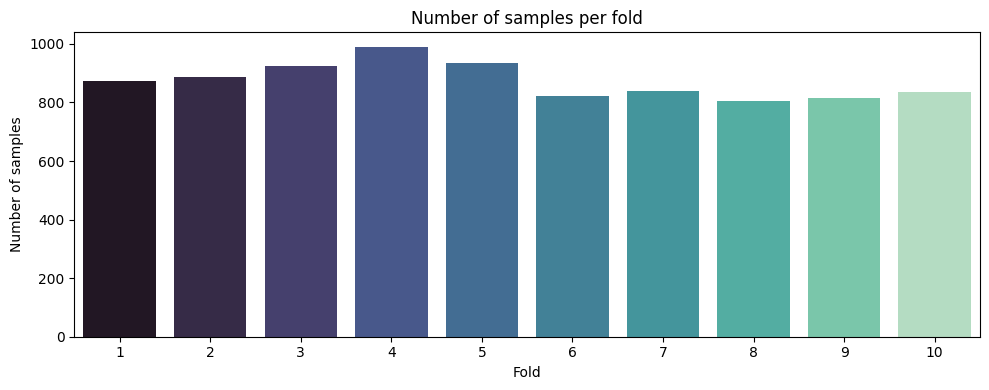

In [11]:
plt.figure(figsize=(10, 4))
sns.countplot(data=metadata, x="fold", palette="mako")
plt.title("Number of samples per fold")
plt.xlabel("Fold")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

In [12]:
durations = metadata["end"] - metadata["start"]
print("Clip duration stats (seconds):")
print(durations.describe())

Clip duration stats (seconds):
count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
dtype: float64


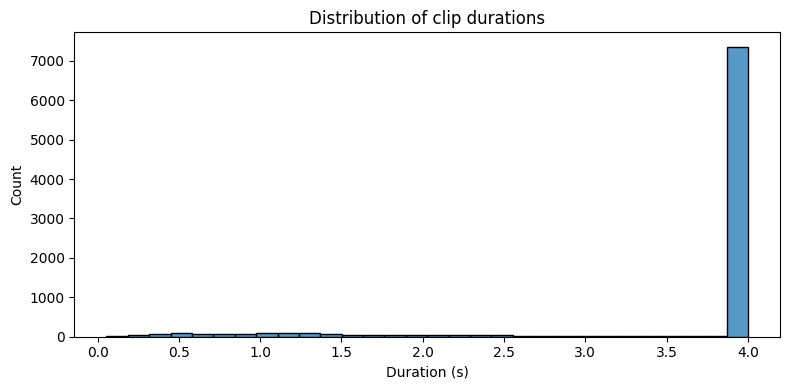

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(durations, bins=30)
plt.title("Distribution of clip durations")
plt.xlabel("Duration (s)")
plt.tight_layout()
plt.show()

In [14]:
sample_per_class = metadata.groupby("class").first().reset_index()

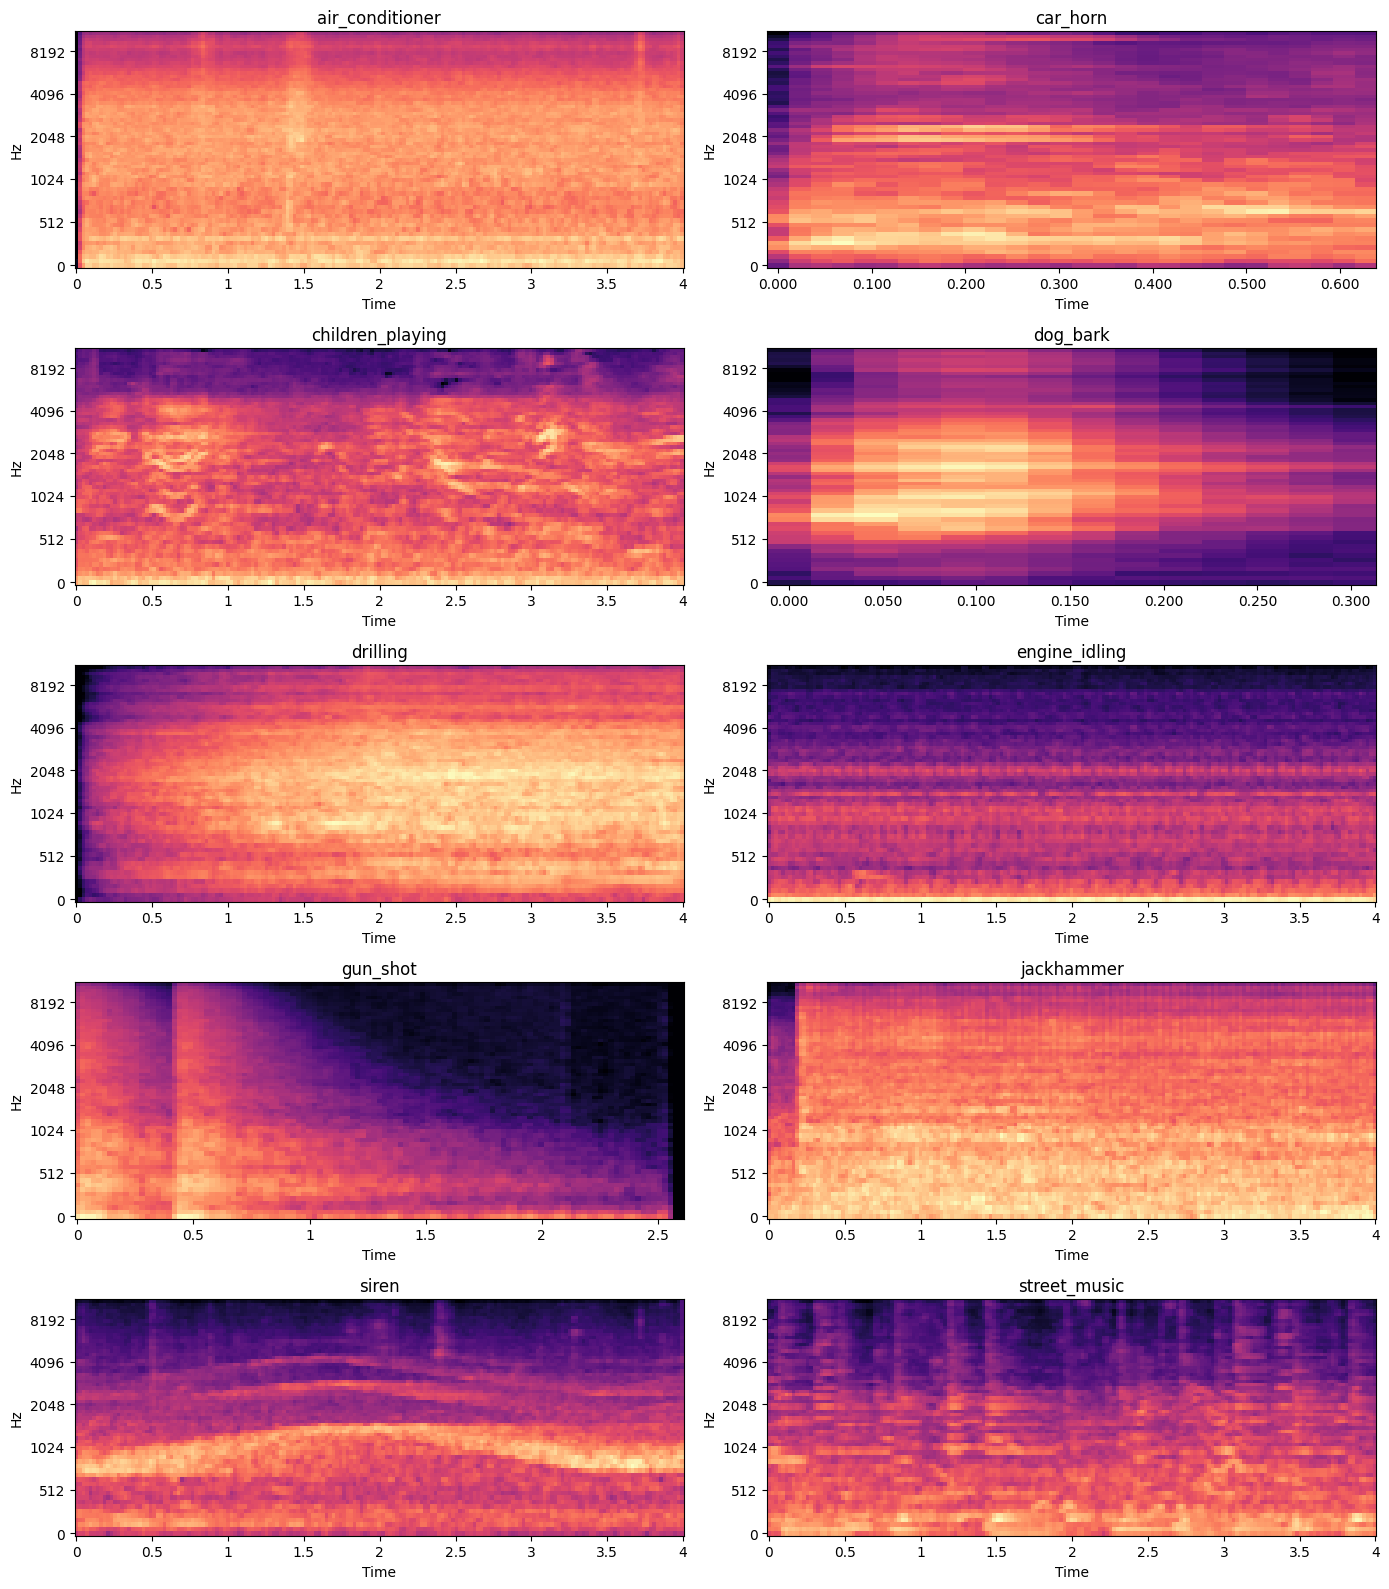

In [15]:
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()
for i, row in sample_per_class.iterrows():
    path = os.path.join(AUDIO_DIR, f"fold{row['fold']}", row["slice_file_name"])
    try:
        y, sr = librosa.load(path, sr=22050)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i])
        axes[i].set_title(row["class"])
    except Exception as e:
        print(f"Could not load sample for '{row['class']}' ({path}): {e}")
        axes[i].set_title(f"{row['class']} (load failed)")
plt.tight_layout()
plt.show()

# 4. FEATURE ENGINEERING

Two feature sets:
- log-mel spectrogram (2D)  -> CNN input
- MFCC averaged over time (1D vector) -> classic ML baseline input

Extraction is done per-file, so it is kept in small helper functions (these are called ~8700 times each, which is the definition of a case where a function is actually needed).

In [16]:
SAMPLE_RATE = 22050
DURATION = 4.0  # seconds - longest clip in UrbanSound8K
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512
MAX_FRAMES = int(np.ceil(SAMPLE_RATE * DURATION / HOP_LENGTH))

In [17]:
def load_audio(path, sr=SAMPLE_RATE, duration=DURATION):
    """Load one audio file, resample, and pad/truncate to a fixed duration."""
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y

In [18]:
def extract_mel_spectrogram(y, sr=SAMPLE_RATE):
    """Compute a normalized, fixed-size log-mel spectrogram for one clip."""
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)  # normalize to [0, 1]
    if mel_db.shape[1] < MAX_FRAMES:
        mel_db = np.pad(mel_db, ((0, 0), (0, MAX_FRAMES - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :MAX_FRAMES]
    return mel_db.astype(np.float32)

In [19]:
def extract_mfcc_mean(y, sr=SAMPLE_RATE, n_mfcc=40):
    """Compute MFCCs and average over time -> fixed-length feature vector."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)

In [20]:
# Run feature extraction over the whole dataset (cached to disk)
CACHE_DIR = "./feature_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
MEL_CACHE = os.path.join(CACHE_DIR, "mel_specs.npy")
MFCC_CACHE = os.path.join(CACHE_DIR, "mfcc_features.npy")
LABELS_CACHE = os.path.join(CACHE_DIR, "labels.npy")
FOLDS_CACHE = os.path.join(CACHE_DIR, "folds.npy")

In [21]:
if all(os.path.exists(p) for p in [MEL_CACHE, MFCC_CACHE, LABELS_CACHE, FOLDS_CACHE]):
    print("Loading cached features...")
    mel_specs = np.load(MEL_CACHE)
    mfcc_feats = np.load(MFCC_CACHE)
    labels = np.load(LABELS_CACHE)
    folds = np.load(FOLDS_CACHE)
else:
    print("Computing features (this may take a few minutes)...")
    mel_specs, mfcc_feats, labels, folds = [], [], [], []

    for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
        path = os.path.join(AUDIO_DIR, f"fold{row['fold']}", row["slice_file_name"])
        try:
            y = load_audio(path)
            mel_specs.append(extract_mel_spectrogram(y))
            mfcc_feats.append(extract_mfcc_mean(y))
            labels.append(row["classID"])
            folds.append(row["fold"])
        except Exception as e:
            print(f"Skipping {path}: {e}")

    mel_specs = np.array(mel_specs)
    mfcc_feats = np.array(mfcc_feats)
    labels = np.array(labels)
    folds = np.array(folds)

    np.save(MEL_CACHE, mel_specs)
    np.save(MFCC_CACHE, mfcc_feats)
    np.save(LABELS_CACHE, labels)
    np.save(FOLDS_CACHE, folds)

Computing features (this may take a few minutes)...


  0%|          | 0/8732 [00:00<?, ?it/s]

In [22]:
print("Mel spectrograms shape:", mel_specs.shape)
print("MFCC features shape:", mfcc_feats.shape)
print("Labels shape:", labels.shape)

Mel spectrograms shape: (8732, 64, 173)
MFCC features shape: (8732, 40)
Labels shape: (8732,)


In [23]:
class_names = metadata[["classID", "class"]].drop_duplicates().sort_values("classID")["class"].tolist()
print("Class names:", class_names)

Class names: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


# 5. TRAIN / VALIDATION / TEST SPLIT

IMPORTANT: UrbanSound8K provides 10 official folds. Clips coming from the same original recording can land in the same fold, so a RANDOM split would leak information between train and test and inflate accuracy. We therefore split strictly by fold number:
- folds 1-8 -> train,
- fold 9 -> validation,
- fold 10 -> test.

In [24]:
train_mask = np.isin(folds, [1, 2, 3, 4, 5, 6, 7, 8])
val_mask = folds == 9
test_mask = folds == 10

print("Train samples:", train_mask.sum())
print("Val samples:  ", val_mask.sum())
print("Test samples: ", test_mask.sum())

Train samples: 7079
Val samples:   816
Test samples:  837


In [25]:
class UrbanSoundDataset(Dataset):
    """PyTorch Dataset wrapping precomputed mel-spectrograms and integer labels."""

    def __init__(self, mel_specs, labels):
        self.mel_specs = mel_specs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.mel_specs[idx], dtype=torch.float32).unsqueeze(0)  # (1, n_mels, frames)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [26]:
BATCH_SIZE = 32

In [27]:
train_ds = UrbanSoundDataset(mel_specs[train_mask], labels[train_mask])
val_ds = UrbanSoundDataset(mel_specs[val_mask], labels[val_mask])
test_ds = UrbanSoundDataset(mel_specs[test_mask], labels[test_mask])

In [28]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
print(f"DataLoaders ready -> train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

DataLoaders ready -> train: 7079, val: 816, test: 837


# 6. MODEL DEFINITION (CNN)

In [30]:
class AudioCNN(nn.Module):
    """A small CNN operating on log-mel spectrograms."""

    def __init__(self, n_classes=10, n_mels=N_MELS, n_frames=MAX_FRAMES):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_mels, n_frames)
            flat_dim = self.conv(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(1)
        return self.classifier(x)

In [31]:
model = AudioCNN(n_classes=len(class_names)).to(DEVICE)
print(model)

AudioCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=10752, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4,

# 7. TRAINING

Train_one_epoch / evaluate are kept as functions because each is called many times (once per epoch, and later again per CV fold) - this is repeated logic, not one-off code.

In [32]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [33]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

In [34]:
EPOCHS = 30
LR = 1e-3
MODEL_PATH = "best_audio_cnn.pt"

In [35]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

In [36]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 01/30 | train_loss=1.8495 train_acc=0.3510 | val_loss=1.5983 val_acc=0.3824
Epoch 02/30 | train_loss=1.3686 train_acc=0.4922 | val_loss=1.3345 val_acc=0.5453
Epoch 03/30 | train_loss=1.1806 train_acc=0.5689 | val_loss=1.7049 val_acc=0.5159
Epoch 04/30 | train_loss=1.0175 train_acc=0.6261 | val_loss=1.1696 val_acc=0.6765
Epoch 05/30 | train_loss=0.9481 train_acc=0.6531 | val_loss=1.5139 val_acc=0.5919
Epoch 06/30 | train_loss=0.8622 train_acc=0.6872 | val_loss=1.3825 val_acc=0.6483
Epoch 07/30 | train_loss=0.7844 train_acc=0.7146 | val_loss=1.2513 val_acc=0.6789
Epoch 08/30 | train_loss=0.7233 train_acc=0.7340 | val_loss=1.6178 val_acc=0.6311
Epoch 09/30 | train_loss=0.6798 train_acc=0.7470 | val_loss=1.5347 val_acc=0.6605
Epoch 10/30 | train_loss=0.6425 train_acc=0.7651 | val_loss=1.4086 val_acc=0.7169
Epoch 11/30 | train_loss=0.5892 train_acc=0.7826 | val_loss=1.5216 val_acc=0.6863
Epoch 12/30 | train_loss=0.5692 train_acc=0.7919 | val_loss=1.6894 val_acc=0.7169
Epoch 13/30 | tr

In [37]:
print(f"Best validation accuracy: {best_val_acc:.4f} (saved to {MODEL_PATH})")

Best validation accuracy: 0.7549 (saved to best_audio_cnn.pt)


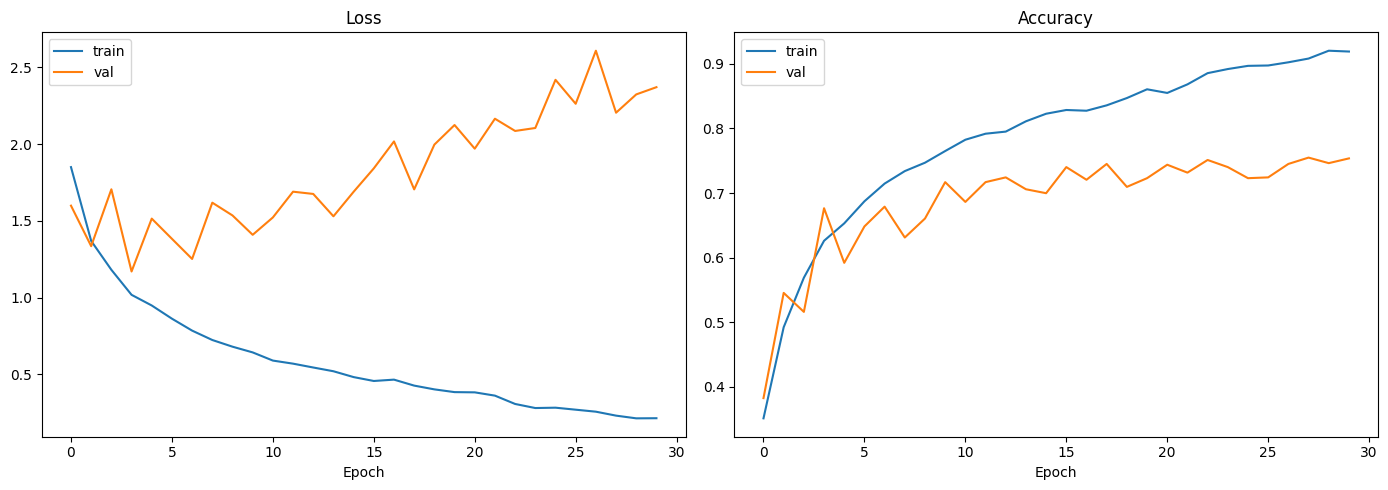

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

# 8. TEST-SET EVALUATION

In [39]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

<All keys matched successfully>

In [40]:
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 1.1648 | Test accuracy: 0.7766


In [41]:
print("Classification report (CNN, test = fold 10):")
print(classification_report(test_labels, test_preds, target_names=class_names))

Classification report (CNN, test = fold 10):
                  precision    recall  f1-score   support

 air_conditioner       0.74      0.67      0.71       100
        car_horn       0.91      0.94      0.93        33
children_playing       0.73      0.74      0.73       100
        dog_bark       0.69      0.71      0.70       100
        drilling       0.79      0.85      0.82       100
   engine_idling       0.80      0.65      0.71        93
        gun_shot       0.97      0.97      0.97        32
      jackhammer       0.90      0.98      0.94        96
           siren       0.82      0.55      0.66        83
    street_music       0.68      0.91      0.78       100

        accuracy                           0.78       837
       macro avg       0.80      0.80      0.79       837
    weighted avg       0.78      0.78      0.77       837



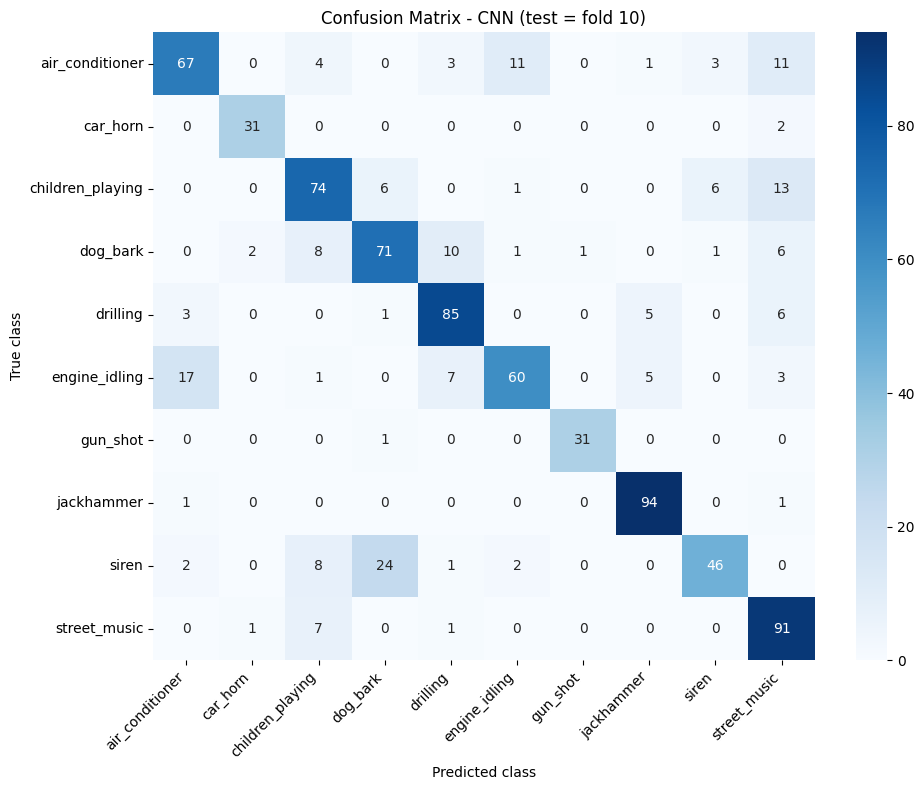

In [42]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - CNN (test = fold 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 9. FULL 10-FOLD CROSS-VALIDATION (OPTIONAL)

Reuses train_one_epoch / evaluate from step 7. Roughly 10x the cost of a single training run, so it's optional. Do this to get the "official" UrbanSound8K style result (mean accuracy over all 10 folds).

In [43]:
fold_accuracies = []
for test_fold in range(1, 11):
    train_mask_cv = folds != test_fold
    test_mask_cv = folds == test_fold

    train_loader_cv = DataLoader(
        UrbanSoundDataset(mel_specs[train_mask_cv], labels[train_mask_cv]),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    test_loader_cv = DataLoader(
        UrbanSoundDataset(mel_specs[test_mask_cv], labels[test_mask_cv]),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    fold_model = AudioCNN(n_classes=len(class_names)).to(DEVICE)
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
    fold_criterion = nn.CrossEntropyLoss()

    for _ in range(15):
        train_one_epoch(fold_model, train_loader_cv, fold_optimizer, fold_criterion)

    _, fold_acc, _, _ = evaluate(fold_model, test_loader_cv, fold_criterion)
    fold_accuracies.append(fold_acc)
    print(f"Fold {test_fold} (test) -> accuracy: {fold_acc:.4f}")

Fold 1 (test) -> accuracy: 0.7434
Fold 2 (test) -> accuracy: 0.6306
Fold 3 (test) -> accuracy: 0.6519
Fold 4 (test) -> accuracy: 0.6293
Fold 5 (test) -> accuracy: 0.7286
Fold 6 (test) -> accuracy: 0.6574
Fold 7 (test) -> accuracy: 0.5990
Fold 8 (test) -> accuracy: 0.6762
Fold 9 (test) -> accuracy: 0.7586
Fold 10 (test) -> accuracy: 0.7372


In [44]:
print(f"Mean 10-fold CV accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")

Mean 10-fold CV accuracy: 0.6812 (+/- 0.0536)


# 10. BASELINE: RANDOM FOREST ON MFCC FEATURES

A classic ML baseline is standard practice: it tells us how much the CNN / deep features are actually buying us over simple averaged MFCCs.

In [45]:
X_train_rf = mfcc_feats[train_mask | val_mask]
y_train_rf = labels[train_mask | val_mask]
X_test_rf = mfcc_feats[test_mask]
y_test_rf = labels[test_mask]

In [46]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED)
rf.fit(X_train_rf, y_train_rf)
rf_preds = rf.predict(X_test_rf)
rf_acc = accuracy_score(y_test_rf, rf_preds)

print(f"Random Forest test accuracy: {rf_acc:.4f}")
print(classification_report(y_test_rf, rf_preds, target_names=class_names))

Random Forest test accuracy: 0.5735
                  precision    recall  f1-score   support

 air_conditioner       0.89      0.40      0.55       100
        car_horn       0.76      0.76      0.76        33
children_playing       0.42      0.70      0.52       100
        dog_bark       0.54      0.70      0.61       100
        drilling       0.41      0.40      0.41       100
   engine_idling       0.80      0.51      0.62        93
        gun_shot       0.83      0.47      0.60        32
      jackhammer       0.65      0.53      0.58        96
           siren       0.63      0.55      0.59        83
    street_music       0.56      0.76      0.65       100

        accuracy                           0.57       837
       macro avg       0.65      0.58      0.59       837
    weighted avg       0.62      0.57      0.57       837



In [47]:
print(f"CNN test accuracy:           {test_acc:.4f}")
print(f"Random Forest test accuracy: {rf_acc:.4f}")

CNN test accuracy:           0.7766
Random Forest test accuracy: 0.5735


# 11. INFERENCE ON A NEW AUDIO FILE

In [48]:
# NEW_FILE_PATH = "./some_new_sound.wav"
# y = load_audio(NEW_FILE_PATH)
# mel = extract_mel_spectrogram(y)
# x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
#
# model.eval()
# with torch.no_grad():
#     logits = model(x)
#     probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
#     pred_idx = int(np.argmax(probs))
#
# print(f"Predicted class: {class_names[pred_idx]} (probability: {probs[pred_idx]:.3f})")
# top3_idx = np.argsort(probs)[::-1][:3]
# print("Top-3 predictions:")
# for i in top3_idx:
#     print(f"  {class_names[i]:20s} {probs[i]:.3f}")